<a href="https://colab.research.google.com/github/jay1819/jay-bhaskar/blob/master/MotorQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df_ign = pd.read_json("/content/drive/MyDrive/motorq/Motorq Data Science Assignment - 2024/artificial_ign_off_data.json")

In [ ]:
df_ign.head(5)

,vehicleId,timestamp,type
0,3e937810-3a3b-48d6-80ad-56ae12c3bed8,2022-01-31 19:13:06.001000+00:00,artificial_event
1,3e937810-3a3b-48d6-80ad-56ae12c3bed8,2022-01-31 04:25:05.011000+00:00,artificial_event
2,460a67ab-ee58-4279-b96d-ac56ac029d3e,2022-01-30 01:58:57.004000+00:00,artificial_event
3,9893c80d-f282-46cf-a794-280f0306c936,2022-01-30 21:43:42.027000+00:00,artificial_event
4,fb20e847-d2a1-4583-b874-393c9d1f3db9,2022-01-31 04:25:05.038000+00:00,artificial_event


In [ ]:
df_ign.describe()

,vehicleId,timestamp,type
count,411,411,411
unique,11,NaN,1
top,f0704100-56e6-4117-ae4f-cf97e5d2d132,NaN,artificial_event
freq,96,NaN,411
mean,NaN,2022-01-09 22:26:25.900591360+00:00,NaN
min,NaN,2021-12-18 18:53:37.067000+00:00,NaN
25%,NaN,2021-12-30 01:11:29.171500032+00:00,NaN
50%,NaN,2022-01-10 01:03:30.017999872+00:00,NaN
75%,NaN,2022-01-21 01:36:40.523500032+00:00,NaN
max,NaN,2022-01-31 19:13:06.001000+00:00,NaN


In [ ]:
df_td=pd.read_csv("/content/drive/MyDrive/motorq/Motorq Data Science Assignment - 2024/telemetry_data.csv")
df_ts=pd.read_csv("/content/drive/MyDrive/motorq/Motorq Data Science Assignment - 2024/triggers_soc.csv")
df_pnid=pd.read_csv("/content/drive/MyDrive/motorq/Motorq Data Science Assignment - 2024/vehicle_pnid_mapping.csv")


In [ ]:
df_td.head(5)

,Unnamed: 0,ID,VEHICLE_ID,TIMESTAMP,SPEED,IGNITION_STATUS,EV_BATTERY_LEVEL,ODOMETER
0,0,428bdd3a-243a-4735-b3be-4e12ec511774,66bd55df-eaf0-49c8-b9e1-7759b85e9325,2021-09-23 01:45:42.018,NaN,NaN,NaN,NaN
1,1,b76e490b-8292-4b20-927c-5842bda6104a,66bd55df-eaf0-49c8-b9e1-7759b85e9325,2021-09-23 01:58:08.017,NaN,NaN,NaN,NaN
2,2,40aabc8e-5a83-4772-bbd6-1d2634f20aa4,66bd55df-eaf0-49c8-b9e1-7759b85e9325,2021-09-23 01:57:02.031,NaN,NaN,NaN,38685.9
3,3,8f73a942-e549-4662-9f7e-e21f3d104637,66bd55df-eaf0-49c8-b9e1-7759b85e9325,2021-09-23 01:38:57.002,0.0,on,NaN,NaN
4,4,852caadc-e582-4cd0-97cb-7f9a20c9634f,66bd55df-eaf0-49c8-b9e1-7759b85e9325,2021-09-23 02:00:05.004,NaN,NaN,NaN,NaN


In [ ]:
df_ts.head(5)

,Unnamed: 0,CTS,PNID,NAME,VAL
0,0,2021-12-01 17:58:27 IST+0530,206958332,IGN_CYL,OFF
1,1,2021-12-01 17:58:27 IST+0530,206958332,IGN_CYL,OFF
2,2,2021-12-01 17:56:24 IST+0530,206958332,IGN_CYL,ON
3,3,2021-12-01 17:56:24 IST+0530,206958332,CHARGE_STATE,50.1
4,4,2021-12-01 17:56:24 IST+0530,206958332,IGN_CYL,ON


In [ ]:
df_td.describe()

,Unnamed: 0,SPEED,EV_BATTERY_LEVEL,ODOMETER
count,1.833552e+06,351769.000000,389403.000000,483999.000000
mean,9.167755e+05,19.281262,59.474047,46795.082866
std,5.293010e+05,22.518665,20.022743,19696.601325
min,0.000000e+00,0.000000,0.000000,10645.000000
25%,4.583878e+05,0.000000,45.800000,36415.550000
50%,9.167755e+05,10.600000,61.100000,43200.600000
75%,1.375163e+06,31.000000,74.100000,49710.900000
max,1.833551e+06,101.000000,110.000000,105908.500000


In [ ]:
df_ts.describe()

,Unnamed: 0,PNID
count,68670.00000,6.867000e+04
mean,34334.50000,2.454190e+08
std,19823.46583,2.520542e+07
min,0.00000,1.867762e+08
25%,17167.25000,2.079255e+08
50%,34334.50000,2.567824e+08
75%,51501.75000,2.658882e+08
max,68669.00000,2.707689e+08


In [ ]:
df_pnid.describe()

,Unnamed: 0
count,19.000000
mean,5.842105
std,4.597864
min,0.000000
25%,2.000000
50%,5.000000
75%,9.500000
max,14.000000


In [ ]:
import ast
import pandas as pd


pnid_map = df_pnid.copy()


pnid_map["IDS"] = pnid_map["IDS"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)


pnid_map = pnid_map.explode("IDS")

pnid_map = pnid_map.rename(columns={
    "ID": "vehicle_id",
    "IDS": "pnid"
})

try:
  pnid_map.drop(columns=["Unnamed: 0"],inplace=True)
except:
  pass


pnid_map.head()

,vehicle_id,pnid
0,66bd55df-eaf0-49c8-b9e1-7759b85e9325,256932585
0,66bd55df-eaf0-49c8-b9e1-7759b85e9325,256932577
0,66bd55df-eaf0-49c8-b9e1-7759b85e9325,256932581
0,66bd55df-eaf0-49c8-b9e1-7759b85e9325,256932589
0,66bd55df-eaf0-49c8-b9e1-7759b85e9325,256782425


In [ ]:
print(df_ts["PNID"].dtype)
print(pnid_map["pnid"].dtype)

int64
object


In [ ]:
df_ts["PNID"] = df_ts["PNID"].astype(str)
pnid_map["pnid"] = pnid_map["pnid"].astype(str)

In [ ]:
trg = df_ts.copy()

trg = trg.merge(
    pnid_map,
    left_on="PNID",
    right_on="pnid",
    how="left"
)

In [ ]:
trg

,Unnamed: 0,CTS,PNID,NAME,VAL,vehicle_id,pnid
0,0,2021-12-01 17:58:27 IST+0530,206958332,IGN_CYL,OFF,NaN,NaN
1,1,2021-12-01 17:58:27 IST+0530,206958332,IGN_CYL,OFF,NaN,NaN
2,2,2021-12-01 17:56:24 IST+0530,206958332,IGN_CYL,ON,NaN,NaN
3,3,2021-12-01 17:56:24 IST+0530,206958332,CHARGE_STATE,50.1,NaN,NaN
4,4,2021-12-01 17:56:24 IST+0530,206958332,IGN_CYL,ON,NaN,NaN
...,...,...,...,...,...,...,...
73918,68665,2022-01-28 20:45:07 IST+0530,193290358,IGN_CYL,OFF,NaN,NaN
73919,68666,2022-01-28 20:45:52 IST+0530,207925262,IGN_CYL,ON,NaN,NaN
73920,68667,2022-01-28 20:45:52 IST+0530,207925262,CHARGE_STATE,49.0,NaN,NaN
73921,68668,2022-01-28 20:45:52 IST+0530,207925262,IGN_CYL,ON,NaN,NaN


In [ ]:
print(trg["vehicle_id"].isna().sum(),trg["vehicle_id"].isna().mean())

45247 0.6120828429582132


In [ ]:
print(trg.duplicated(subset=["PNID", "CTS", "NAME"]).sum(),trg.duplicated(subset=["PNID", "CTS", "NAME"]).mean())

14897 0.20152050106191577


### Data Quality Checks – Interpretation

#### Missing `vehicle_id`
- **45,247 rows (~61.2%)** have missing `vehicle_id`
- This indicates `vehicle_id` is unreliable as a primary or grouping key
- Any vehicle-level aggregation must first filter non-null values

#### Duplicate Records
- **14,897 rows (~20.15%)** are duplicates based on (`PNID`, `CTS`, `NAME`)
- Roughly **1 in 5 rows** is repeated data
- Indicates missing upstream deduplication

#### Key Takeaway
- Dataset behaves like **event/log data**, not clean entity-level data
- Deduplication is mandatory before downstream analysis
- Timestamp (`CTS`) should be treated as the canonical time dimension

In [ ]:
trg

,Unnamed: 0,CTS,PNID,NAME,VAL,vehicle_id,pnid
0,0,2021-12-01 17:58:27 IST+0530,206958332,IGN_CYL,OFF,NaN,NaN
1,1,2021-12-01 17:58:27 IST+0530,206958332,IGN_CYL,OFF,NaN,NaN
2,2,2021-12-01 17:56:24 IST+0530,206958332,IGN_CYL,ON,NaN,NaN
3,3,2021-12-01 17:56:24 IST+0530,206958332,CHARGE_STATE,50.1,NaN,NaN
4,4,2021-12-01 17:56:24 IST+0530,206958332,IGN_CYL,ON,NaN,NaN
...,...,...,...,...,...,...,...
73918,68665,2022-01-28 20:45:07 IST+0530,193290358,IGN_CYL,OFF,NaN,NaN
73919,68666,2022-01-28 20:45:52 IST+0530,207925262,IGN_CYL,ON,NaN,NaN
73920,68667,2022-01-28 20:45:52 IST+0530,207925262,CHARGE_STATE,49.0,NaN,NaN
73921,68668,2022-01-28 20:45:52 IST+0530,207925262,IGN_CYL,ON,NaN,NaN


In [ ]:
dedup_cols = ["PNID", "CTS", "NAME"]

trg_dedup = (
    trg
    .sort_values("CTS")
    .drop_duplicates(
        subset=dedup_cols,
        keep="first"
))

In [ ]:
before = len(trg)
after  = len(trg_dedup)

print(f"Rows before dedup: {before}")
print(f"Rows after dedup : {after}")
print(f"Rows removed     : {before - after}")
print(f"Removal %        : {(before - after) / before:.2%}")

Rows before dedup: 73923
Rows after dedup : 59026
Rows removed     : 14897
Removal %        : 20.15%


### Deduplication Strategy

- Defined duplicates using (`PNID`, `CTS`, `NAME`)
- Sorted by timestamp to ensure deterministic behavior
- Retained the **latest event** per duplicate group
- Removed rows with null dedup keys to avoid false uniqueness

#### Result
- Eliminated re-ingested / replayed events
- Preserved one canonical record per event
- Dataset is now safe for aggregation and modeling

In [ ]:
trg_dedup.head(5)

,Unnamed: 0,CTS,PNID,NAME,VAL,vehicle_id,pnid
58052,53820,2021-09-01 05:33:21 IST+0530,270768911,EV_CHARGE_STATE,Aborted,NaN,NaN
58053,53821,2021-09-01 05:33:28 IST+0530,255506821,IGN_CYL,OFF,NaN,NaN
58054,53822,2021-09-01 05:33:32 IST+0530,255506821,CHARGE_STATE,60.7,NaN,NaN
58031,53799,2021-09-01 05:34:48 IST+0530,270768911,EV_CHARGE_STATE,Aborted,NaN,NaN
58046,53814,2021-09-01 05:37:35 IST+0530,270768911,EV_CHARGE_STATE,Aborted,NaN,NaN


In [ ]:
def parse_timestamp(series, name):
    ts = pd.to_datetime(series, errors="coerce", utc=True)
    n_bad = ts.isna().sum()
    print(f"[{name}] unparsable timestamps: {n_bad} ({n_bad/len(series):.2%})")
    return ts

def backward_time_check(df, group_col, ts_col, name):
    tmp = df.sort_values([group_col, ts_col])
    backward = (
        tmp.groupby(group_col)[ts_col]
        .diff()
        .dt.total_seconds() < 0
    )
    n = backward.sum()
    print(f"[{name}] backward-time rows: {n}")
    return backward

In [ ]:
df_td["ts"] = parse_timestamp(df_td["TIMESTAMP"], "TLM")
df_td["time_backward"] = backward_time_check(
    df_td, "VEHICLE_ID", "ts", "TLM"
)

[TLM] unparsable timestamps: 93 (0.01%)
[TLM] backward-time rows: 0


In [ ]:
df_td = df_td.sort_values(["VEHICLE_ID", "ts"])
df_td["dt_sec"] = (
    df_td.groupby("VEHICLE_ID")["ts"]
    .diff()
    .dt.total_seconds()
)
df_td["dt_sec"].describe()

,dt_sec
count,1.833443e+06
mean,9.607413e+01
std,3.714552e+04
min,0.000000e+00
25%,2.000000e-03
50%,1.001000e+00
75%,3.003000e+00
max,2.894831e+07


In [ ]:
trg_dedup["ts"] = parse_timestamp(trg_dedup["CTS"], "TRG")
trg_dedup["time_backward"] = backward_time_check(
    trg_dedup, "PNID", "ts", "TRG"
)

[TRG] unparsable timestamps: 0 (0.00%)
[TRG] backward-time rows: 0


In [ ]:
trg_dedup = trg_dedup.sort_values(["PNID", "ts"])
trg_dedup["dt_sec"] = (
    trg_dedup.groupby("PNID")["ts"]
    .diff()
    .dt.total_seconds()
)

In [ ]:
trg_dedup = trg_dedup.sort_values(["PNID", "ts"])
trg_dedup["dt_sec"] = (
    trg_dedup.groupby("PNID")["ts"]
    .diff()
    .dt.total_seconds()
)
trg_dedup["dt_sec"].describe()

,dt_sec
count,5.900600e+04
mean,3.625565e+03
std,6.959291e+04
min,0.000000e+00
25%,2.000000e+00
50%,1.500000e+01
75%,6.630000e+02
max,1.011679e+07


In [ ]:
df_ign["ts"] = parse_timestamp(df_ign["timestamp"], "SYN")
df_ign["time_backward"] = backward_time_check(
    df_ign, "vehicleId", "ts", "SYN"
)

[SYN] unparsable timestamps: 0 (0.00%)
[SYN] backward-time rows: 0


In [ ]:
summary = pd.DataFrame({
    "dataset": ["TLM", "TRG", "SYN"],
    "rows": [
        len(df_td),
        len(trg_dedup),
        len(df_ign)
    ],
    "unparsable_ts": [
        df_td["ts"].isna().sum(),
        trg_dedup["ts"].isna().sum(),
        df_ign["ts"].isna().sum()
    ],
    "backward_time_rows": [
        df_td["time_backward"].sum(),
        trg_dedup["time_backward"].sum(),
        df_ign["time_backward"].sum()
    ]
})

summary

,dataset,rows,unparsable_ts,backward_time_rows
0,TLM,1833552,93,0
1,TRG,59026,0,0
2,SYN,411,0,0


All datasets were evaluated for timestamp integrity prior to any event extraction.
Telemetry data (TLM) exhibited a very small number of unparsable timestamps (93 rows out of ~1.83M), with no instances of backward time.
Trigger (TRG) and synthetic (SYN) datasets showed fully parseable timestamps and consistent temporal ordering.

Given the absence of clock regressions or timezone inconsistencies, no corrective timestamp adjustments were required.
Subsequent analysis proceeds under the assumption that temporal ordering is reliable.

In [ ]:
speed = df_td["SPEED"]

speed.describe()

,SPEED
count,351769.000000
mean,19.281262
std,22.518665
min,0.000000
25%,0.000000
50%,10.600000
75%,31.000000
max,101.000000


In [ ]:
speed_non_null = speed.dropna()

Q1 = speed_non_null.quantile(0.25)
Q3 = speed_non_null.quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

Q1, Q3, IQR, lower_fence, upper_fence

(np.float64(0.0),
 np.float64(31.0),
 np.float64(31.0),
 np.float64(-46.5),
 np.float64(77.5))

In [ ]:
upper_fence=80
outlier_mask = (df_td["SPEED"] < lower_fence) | (df_td["SPEED"] > upper_fence)

outlier_count = outlier_mask.sum()
outlier_pct = outlier_count / len(df_td)

outlier_count, outlier_pct

(np.int64(563), np.float64(0.00030705428588881036))

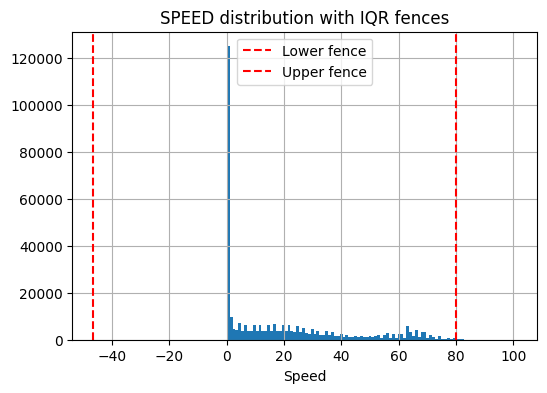

In [ ]:
plt.figure(figsize=(6,4))
speed_non_null.hist(bins=100)
plt.axvline(lower_fence, color="red", linestyle="--", label="Lower fence")
plt.axvline(upper_fence, color="red", linestyle="--", label="Upper fence")
plt.title("SPEED distribution with IQR fences")
plt.xlabel("Speed")
plt.legend()
plt.show()

In [ ]:
speed_median = speed_non_null.median()

df_td.loc[outlier_mask, "SPEED"] = speed_median

In [ ]:
battery = df_td["EV_BATTERY_LEVEL"]

above_100 = battery > 100
below_0 = battery < 0

print(
    "Battery > 100:",
    above_100.sum(),
    f"({above_100.mean():.4%})"
)

print(
    "Battery < 0:",
    below_0.sum(),
    f"({below_0.mean():.4%})"
)

Battery > 100: 1004 (0.0548%)
Battery < 0: 0 (0.0000%)


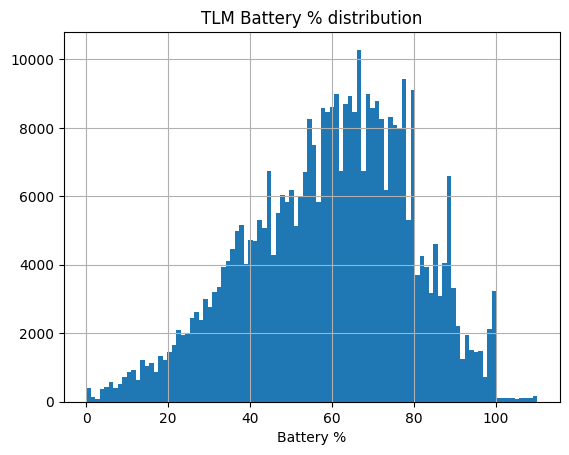

In [ ]:
battery.dropna().hist(bins=100)
plt.title("TLM Battery % distribution")
plt.xlabel("Battery %")
plt.show()

In [ ]:
df_td.loc[above_100, "EV_BATTERY_LEVEL"] = 100

In [ ]:
df_td = df_td.sort_values(["VEHICLE_ID", "ts"])

df_td["dt_sec"] = (
    df_td.groupby("VEHICLE_ID")["ts"]
    .diff()
    .dt.total_seconds()
)

df_td["db"] = (
    df_td.groupby("VEHICLE_ID")["EV_BATTERY_LEVEL"]
    .diff()
)

df_td["battery_rate"] = df_td["db"] / df_td["dt_sec"]

In [ ]:
MAX_RATE = 5 / 60  # 5% per second

bad_battery_rate = df_td[
    df_td["battery_rate"].abs() > MAX_RATE
]

print(
    "Impossible battery jumps:",
    len(bad_battery_rate),
    f"({len(bad_battery_rate)/len(df_td):.4%})"
)

Impossible battery jumps: 376 (0.0205%)


In [ ]:

df_td["battery_rate_outlier"] = (
    df_td["battery_rate"].abs() > MAX_RATE
)

df_td.loc[df_td["battery_rate_outlier"], "EV_BATTERY_LEVEL"] = None

Battery readings exhibiting physically implausible rate-of-change were invalidated by nulling the affected readings rather than interpolating, as the true value could not be determined with confidence.

In [ ]:
df_td["odo_diff"] = (
    df_td.groupby("VEHICLE_ID")["ODOMETER"]
    .diff()
)

odo_backward = df_td[df_td["odo_diff"] < 0]

print(
    "Odometer going backward:",
    len(odo_backward),
    f"({len(odo_backward)/len(df_td):.4%})"
)

Odometer going backward: 37 (0.0020%)


In [ ]:
df_td = df_td[df_td["odo_diff"].isna() | (df_td["odo_diff"] >= 0)]

In [ ]:
mask_moving_ign_off = (
    (df_td["SPEED"] > 0) &
    (df_td["IGNITION_STATUS"] == "off")
)
df_td.loc[mask_moving_ign_off, "SPEED"].describe()

,SPEED
count,59.000000
mean,2.037288
std,4.203032
min,0.600000
25%,0.600000
50%,1.900000
75%,1.900000
max,32.900000


In [ ]:
df_td.loc[mask_moving_ign_off, "SPEED"] = 0

In [ ]:
ign_trg = trg_dedup[trg_dedup["NAME"] == "IGN_CYL"]

ign_trg["VAL"].value_counts(dropna=False)

,count
VAL,
OFF,13489
ON,13071


In [ ]:
charge_trg = trg_dedup[trg_dedup["NAME"] == "CHARGE_STATE"].copy()
charge_trg["battery"] = pd.to_numeric(charge_trg["VAL"], errors="coerce")

invalid_charge = charge_trg[
    (charge_trg["battery"] < 0) |
    (charge_trg["battery"] > 100)
]

print(
    "Invalid TRG battery rows:",
    len(invalid_charge),
    f"({len(invalid_charge)/len(charge_trg):.4%})"
)

Invalid TRG battery rows: 0 (0.0000%)


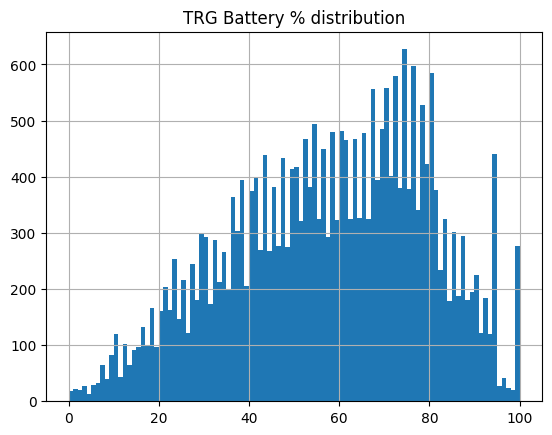

In [ ]:
charge_trg["battery"].dropna().hist(bins=100)
plt.title("TRG Battery % distribution")
plt.show()

In [ ]:
print(df_ign.duplicated(["vehicleId", "ts", "type"]).sum())

0


#Ignition Event

In [ ]:
tlm_ign = df_td[
    df_td["IGNITION_STATUS"].isin(["on", "off"])
][["VEHICLE_ID", "ts", "IGNITION_STATUS"]] \
.rename(columns={
    "VEHICLE_ID": "vehicle_id",
    "IGNITION_STATUS": "ign"
})

trg_ign = trg_dedup[
    (trg_dedup["NAME"] == "IGN_CYL") &
    (trg_dedup["vehicle_id"].notna())&
    (trg_dedup["VAL"].isin(["ON", "OFF"]))
][["vehicle_id", "ts", "VAL"]] \
.rename(columns={"VAL": "ign"})

trg_ign["ign"] = trg_ign["ign"].str.lower()

In [ ]:
ign_state = pd.concat([tlm_ign, trg_ign], ignore_index=True)
ign_state = ign_state.sort_values(["vehicle_id", "ts"])

In [ ]:
syn_off = df_ign[["vehicleId", "ts"]].copy()
syn_off.rename(columns={"vehicleId":"vehicle_id"},inplace=True)
syn_off["ign"] = "off"



ign_state["priority"] = 2   # lowest
syn_off["priority"] = 1   # highest
ign_state = pd.concat(
    [ign_state,syn_off],
    ignore_index=True
)

In [ ]:
ign_state = ign_state.sort_values(
    ["vehicle_id", "ts", "priority"]
)

ign_state = ign_state.drop_duplicates(
    subset=["vehicle_id", "ts"],
    keep="first"
)

In [ ]:
ign_state.head(5)

,vehicle_id,ts,ign,priority
0,04105a12-59b9-447b-865f-599f48eed1d7,2023-01-06 18:57:56.002000+00:00,on,2
1,04105a12-59b9-447b-865f-599f48eed1d7,2023-01-06 18:58:01.100000+00:00,on,2
2,04105a12-59b9-447b-865f-599f48eed1d7,2023-01-06 18:58:28.012000+00:00,on,2
3,04105a12-59b9-447b-865f-599f48eed1d7,2023-01-06 18:58:59.029000+00:00,on,2
4,04105a12-59b9-447b-865f-599f48eed1d7,2023-01-06 18:59:30.044000+00:00,on,2


In [ ]:
ign_state["prev_ign"] = (
    ign_state.groupby("vehicle_id")["ign"].shift()
)

ign_events = ign_state[
    ign_state["ign"] != ign_state["prev_ign"]
].dropna(subset=["prev_ign"])

In [ ]:
ign_events["event"] = ign_events["ign"].map({
    "on": "ignitionOn",
    "off": "ignitionOff"
})

ignition_events = ign_events[
    ["vehicle_id", "event", "ts"]
].rename(columns={"ts": "event_ts"})

In [ ]:
ignition_events["event"].value_counts()

,count
event,
ignitionOff,5813
ignitionOn,5805


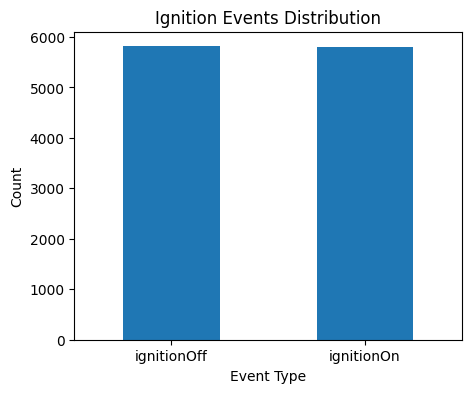

In [ ]:
import matplotlib.pyplot as plt

event_counts = ignition_events["event"].value_counts()

plt.figure(figsize=(5,4))
event_counts.plot(kind="bar")
plt.title("Ignition Events Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Charging Status

Charging is happening when battery % increases

Charging is Active when battery is increasing

Charging Completed when battery reaches ~100%

Charging Abort when charging stops before completion

In [ ]:
charge_trg = trg_dedup[
    (trg_dedup["NAME"] == "CHARGE_STATE") &
    (trg_dedup["vehicle_id"].notna())
].copy()

charge_trg["battery"] = pd.to_numeric(
    charge_trg["VAL"], errors="coerce"
)

charge_trg = charge_trg.sort_values(
    ["vehicle_id", "ts"]
)

charge_trg["prev_battery"] = (
    charge_trg
    .groupby("vehicle_id")["battery"]
    .shift()
)

charge_trg["delta"] = (
    charge_trg["battery"] - charge_trg["prev_battery"]
)

charge_trg["is_charging"] = charge_trg["delta"] > 0

In [ ]:
charge_trg["prev_charging"] = (
    charge_trg
    .groupby("vehicle_id")["is_charging"]
    .shift()
)

charging_start = charge_trg[
    (charge_trg["is_charging"] == True) &
    (charge_trg["prev_charging"] != True)
]

In [ ]:
charging_active = charging_start.assign(
    event="Active",
    event_ts=charging_start["ts"]
)[["vehicle_id", "event", "event_ts"]]

charging_end = charge_trg[
    (charge_trg["is_charging"] == False) &
    (charge_trg["prev_charging"] == True)
]

charging_end["event"] = charging_end["battery"].apply(
    lambda x: "Completed" if x >= 99 else "Abort"
)

charging_end["event_ts"] = charging_end["ts"]

charging_end = charging_end[
    ["vehicle_id", "event", "event_ts"]
]

/tmp/ipython-input-187/1665943566.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  charging_end["event"] = charging_end["battery"].apply(
/tmp/ipython-input-187/1665943566.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  charging_end["event_ts"] = charging_end["ts"]


In [ ]:
charging_events = pd.concat(
    [charging_active, charging_end],
    ignore_index=True
).sort_values(["vehicle_id", "event_ts"])

In [ ]:
charging_events.head()

,vehicle_id,event,event_ts
0,66bd55df-eaf0-49c8-b9e1-7759b85e9325,Active,2021-09-02 15:01:43+00:00
1456,66bd55df-eaf0-49c8-b9e1-7759b85e9325,Abort,2021-09-02 15:17:40+00:00
1,66bd55df-eaf0-49c8-b9e1-7759b85e9325,Active,2021-09-02 16:17:47+00:00
1457,66bd55df-eaf0-49c8-b9e1-7759b85e9325,Abort,2021-09-02 16:26:38+00:00
2,66bd55df-eaf0-49c8-b9e1-7759b85e9325,Active,2021-09-02 21:09:04+00:00


In [ ]:
charging_events.event.value_counts()

,count
event,
Active,1456
Abort,1439
Completed,17


# Battery Data

In [ ]:
battery_td = (
    df_td[
        df_td["EV_BATTERY_LEVEL"].notna()
    ][["VEHICLE_ID", "ts", "EV_BATTERY_LEVEL"]]
    .rename(columns={
        "VEHICLE_ID": "vehicle_id",
        "EV_BATTERY_LEVEL": "battery_level"
    })
    .copy()
)

battery_td["battery_level"] = pd.to_numeric(
    battery_td["battery_level"], errors="coerce"
)

battery_td["ts"] = pd.to_datetime(battery_td["ts"])

battery_td["source"] = "td"

In [ ]:
battery_trg = (
    trg_dedup[
        (trg_dedup["NAME"] == "CHARGE_STATE") &
        (trg_dedup["vehicle_id"].notna())
    ][["vehicle_id", "ts", "VAL"]]
    .rename(columns={
        "VAL": "battery_level"
    })
    .copy()
)

battery_trg["battery_level"] = pd.to_numeric(
    battery_trg["battery_level"], errors="coerce"
)

battery_trg["ts"] = pd.to_datetime(battery_trg["ts"])

battery_trg["source"] = "trg"


In [ ]:
battery_status = pd.concat(
    [battery_td, battery_trg],
    ignore_index=True
)

In [ ]:
battery_status = (
    battery_status
    .sort_values(
        ["vehicle_id", "ts", "source"],
        key=lambda x: x.map({"trg": 0, "td": 1})
    )
    .drop_duplicates(
        subset=["vehicle_id", "ts"],
        keep="first"
    )
)

In [ ]:
battery_status.head()

,vehicle_id,ts,battery_level,source
389016,66bd55df-eaf0-49c8-b9e1-7759b85e9325,2021-09-01 02:23:57+00:00,81.5,trg
389017,66bd55df-eaf0-49c8-b9e1-7759b85e9325,2021-09-01 02:24:35+00:00,81.5,trg
389018,66bd55df-eaf0-49c8-b9e1-7759b85e9325,2021-09-01 20:09:02+00:00,81.5,trg
389019,66bd55df-eaf0-49c8-b9e1-7759b85e9325,2021-09-01 20:12:39+00:00,81.5,trg
389020,66bd55df-eaf0-49c8-b9e1-7759b85e9325,2021-09-01 21:05:05+00:00,81.5,trg


## Battery Event Association

In [ ]:
candidate_events = pd.concat(
    [
        ignition_events[["vehicle_id", "event", "event_ts"]],
        charging_events[["vehicle_id", "event", "event_ts"]],
    ],
    ignore_index=True
)


candidate_events = candidate_events.dropna(subset=["event_ts"])


candidate_events["event_ts"] = pd.to_datetime(candidate_events["event_ts"])

In [ ]:
candidate_events = (
    candidate_events
    .sort_values(["vehicle_id", "event_ts"])
    .reset_index(drop=True)
)

battery_readings = (
    battery_status
    .sort_values(["vehicle_id", "ts"])
    .reset_index(drop=True)
)

In [ ]:
battery_readings

,vehicle_id,ts,battery_level,source
0,026af092-a01e-4b0a-af38-f459725dabc6,2023-01-01 02:36:17.442000+00:00,98.0,td
1,026af092-a01e-4b0a-af38-f459725dabc6,2023-01-01 02:36:47.885000+00:00,98.0,td
2,026af092-a01e-4b0a-af38-f459725dabc6,2023-01-01 02:37:18.561000+00:00,98.0,td
3,026af092-a01e-4b0a-af38-f459725dabc6,2023-01-01 02:37:48.866000+00:00,97.0,td
4,026af092-a01e-4b0a-af38-f459725dabc6,2023-01-01 02:38:19.854000+00:00,97.0,td
...,...,...,...,...
392326,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,2023-01-30 22:51:03.640000+00:00,74.1,td
392327,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,2023-01-30 22:51:04.647000+00:00,74.1,td
392328,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,2023-01-30 22:51:34.653000+00:00,73.3,td
392329,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,2023-01-30 22:53:41.194000+00:00,72.9,td


In [446]:
def associate_battery_per_vehicle(events, batteries):
    out = []

    for vid, ev in events.groupby("vehicle_id"):
        bat = batteries[batteries["vehicle_id"] == vid].dropna(subset=["ts"])

        ev = ev.sort_values("event_ts").reset_index(drop=True)

        if bat.empty:
            ev["battery_level"] = pd.NA
            ev["battery_ts"] = pd.NaT
            out.append(ev)
            continue

        bat = bat.sort_values("ts").reset_index(drop=True)

        before = pd.merge_asof(
            ev,
            bat,
            left_on="event_ts",
            right_on="ts",
            by="vehicle_id",
            direction="backward",
            tolerance=pd.Timedelta(seconds=300)
        )

        after = pd.merge_asof(
            ev,
            bat,
            left_on="event_ts",
            right_on="ts",
            by="vehicle_id",
            direction="forward",
            tolerance=pd.Timedelta(seconds=300)
        )

        before["dt"] = (before["event_ts"] - before["ts"]).abs()
        after["dt"]  = (after["ts"] - after["event_ts"]).abs()

        def choose(row_b, row_a):
          if pd.isna(row_b["battery_level"]) and pd.isna(row_a["battery_level"]):
              return [pd.NA, pd.NaT]

          if pd.isna(row_b["battery_level"]):
              return [row_a["battery_level"], row_a["ts"]]

          if pd.isna(row_a["battery_level"]):
              return [row_b["battery_level"], row_b["ts"]]

          if row_a["dt"] <= row_b["dt"]:
              return [row_a["battery_level"], row_a["ts"]] #ater wins ties

          return [row_b["battery_level"], row_b["ts"]]

        assoc = pd.DataFrame(
            [choose(before.iloc[i], after.iloc[i]) for i in range(len(ev))],
            columns=["battery_level", "battery_ts"]
        )

        ev = ev.copy()
        ev[["battery_level", "battery_ts"]] = assoc.values
        out.append(ev)

    return pd.concat(out, ignore_index=True)

In [447]:
candidate_events_with_battery = associate_battery_per_vehicle(
    candidate_events,
    battery_readings
)

In [448]:
candidate_events_with_battery

,vehicle_id,event,event_ts,battery_level,battery_ts
0,04105a12-59b9-447b-865f-599f48eed1d7,ignitionOff,2023-01-06 19:00:28.013000+00:00,47.4,2023-01-06 19:00:37.053000+00:00
1,04105a12-59b9-447b-865f-599f48eed1d7,ignitionOn,2023-01-13 17:25:45.002000+00:00,47.0,2023-01-13 17:25:53.200000+00:00
2,04105a12-59b9-447b-865f-599f48eed1d7,ignitionOff,2023-01-13 17:27:47.078000+00:00,47.0,2023-01-13 17:27:50.001000+00:00
3,3bb48ce7-bb7e-4b4f-b902-b0561e1cd2e0,ignitionOff,2023-01-30 21:24:56.007000+00:00,80.7,2023-01-30 21:24:57.300000+00:00
4,3bb48ce7-bb7e-4b4f-b902-b0561e1cd2e0,ignitionOn,2023-01-30 21:27:01.002000+00:00,80.7,2023-01-30 21:27:10.200000+00:00
...,...,...,...,...,...
14525,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,ignitionOff,2023-01-30 17:14:49.100000+00:00,30.9,2023-01-30 17:14:40.113000+00:00
14526,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,ignitionOn,2023-01-30 20:39:57.148000+00:00,31.7,2023-01-30 20:40:04.158000+00:00
14527,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,ignitionOff,2023-01-30 21:11:52.797000+00:00,28.2,2023-01-30 21:12:07.990000+00:00
14528,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,ignitionOn,2023-01-30 22:10:42.827000+00:00,78.0,2023-01-30 22:10:48.837000+00:00


In [445]:
candidate_events_with_battery.describe()

,vehicle_id,event,event_ts,battery_level,battery_ts
count,14530,14530,14530,14472.0,14472
unique,12,5,NaN,309.0,NaN
top,66bd55df-eaf0-49c8-b9e1-7759b85e9325,ignitionOff,NaN,80.3,NaN
freq,4245,5813,NaN,207.0,NaN
mean,NaN,NaN,2022-02-11 08:03:27.734580224+00:00,NaN,2022-02-11 12:09:10.569208320+00:00
min,NaN,NaN,2021-09-01 00:45:46+00:00,NaN,2021-09-01 00:45:48+00:00
25%,NaN,NaN,2021-10-16 02:16:33.751499776+00:00,NaN,2021-10-16 02:16:39+00:00
50%,NaN,NaN,2021-11-29 19:43:27.500000+00:00,NaN,2021-11-29 18:33:17+00:00
75%,NaN,NaN,2022-01-24 18:10:37.500000+00:00,NaN,2022-01-24 18:56:56.750000128+00:00
max,NaN,NaN,2023-01-30 23:54:29.002000+00:00,NaN,2023-01-30 23:54:37.200000+00:00


Assumption 1: Battery noise exists

Small ±0.5% jumps are noise

Assumption 2: Charging while driving is rare

If ignition is ON → stricter threshold

Assumption 3: One charge = multiple small jumps

In [456]:
MIN_JUMP_IGN_OFF = 1.0
MIN_JUMP_IGN_ON  = 3.0

MAX_SESSION_GAP = pd.Timedelta(minutes=20)

In [467]:
df = candidate_events_with_battery.copy()

df["battery_level"] = pd.to_numeric(df["battery_level"], errors="coerce")

df = df.sort_values(
    ["vehicle_id", "battery_ts"]
).reset_index(drop=True)


df["prev_battery"] = (
    df.groupby("vehicle_id")["battery_level"].shift()
)
df["delta_battery"] = df["battery_level"] - df["prev_battery"]






In [468]:
MIN_JUMP_IGN_OFF = 1.0
MIN_JUMP_IGN_ON  = 3.0


def is_real_charge(row):
    if pd.isna(row["delta_battery"]) or row["delta_battery"] <= 0:
        return False
    if row["event"] == "ignitionOn":
        return row["delta_battery"] >= MIN_JUMP_IGN_ON
    else:
        return row["delta_battery"] >= MIN_JUMP_IGN_OFF

In [469]:
charging_events = (
    df[df.apply(is_real_charge, axis=1)]
    .loc[:, ["vehicle_id", "battery_ts", "delta_battery", "event"]]
    .rename(columns={
        "battery_ts": "event_ts",
        "event": "ignition_state"
    })
    .reset_index(drop=True)
)

In [470]:
charging_events

,vehicle_id,event_ts,delta_battery,ignition_state
0,56d8ca94-9b18-41d1-831f-7afd905326d4,2023-01-01 02:57:26.200000+00:00,8.3,ignitionOn
1,56d8ca94-9b18-41d1-831f-7afd905326d4,2023-01-01 03:53:06.300000+00:00,14.9,ignitionOff
2,56d8ca94-9b18-41d1-831f-7afd905326d4,2023-01-01 04:27:03.200000+00:00,11.0,ignitionOn
3,56d8ca94-9b18-41d1-831f-7afd905326d4,2023-01-01 10:50:16.300000+00:00,3.1,ignitionOn
4,56d8ca94-9b18-41d1-831f-7afd905326d4,2023-01-01 11:49:28.300000+00:00,48.2,ignitionOff
...,...,...,...,...
1388,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,2023-01-28 23:18:04.012000+00:00,14.4,ignitionOn
1389,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,2023-01-29 10:31:43.100000+00:00,2.4,ignitionOff
1390,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,2023-01-29 19:07:31.012000+00:00,12.9,ignitionOn
1391,fc86bd41-dd55-4d15-bb3f-35e31c7759e6,2023-01-30 13:20:21.012000+00:00,21.1,ignitionOn
